## **EJERCICIO CON "bateria_tableta.txt"**

In [3]:
# Leer el archivo "bateria_tableta.txt"
import pandas as pd

df_bateria = pd.read_csv("bateria_tableta.txt")
df_bateria

,carga,duracion
0,2.81,5.62
1,7.14,8.00
2,2.72,5.44
3,3.87,7.74
4,1.90,3.80
...,...,...
95,4.38,8.00
96,8.06,8.00
97,8.05,8.00
98,1.10,2.20


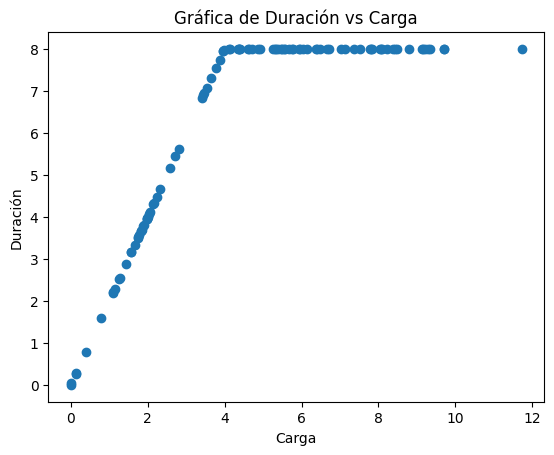

In [4]:
# Gráfica de los datos iniciales de batería
import matplotlib.pyplot as plt

plt.scatter(df_bateria["carga"], df_bateria["duracion"])
plt.xlabel("Carga")
plt.ylabel("Duración")
plt.title("Gráfica de Duración vs Carga")
plt.show()

## MODELO - B0 + B1X

In [5]:
# Paqueterías faltantes
import numpy as np
from sklearn.linear_model import LinearRegression

In [6]:
# Variables del ejercicio de batería
x_bateria = df_bateria[["carga"]]
y_bateria = df_bateria[["duracion"]]

In [7]:
# Modelo de primer orden de batería
modelo_bateria_1 = LinearRegression()
modelo_bateria_1.fit(x_bateria, y_bateria)

predicciones_bateria_1 = modelo_bateria_1.predict(x_bateria)
R2_bateria_1 = modelo_bateria_1.score(x_bateria, y_bateria)

print(f"R² del modelo de primer orden: {R2_bateria_1:.6f}")
print(f"Porcentaje explicado: {R2_bateria_1 * 100:.2f}%")

R² del modelo de primer orden: 0.687227
Porcentaje explicado: 68.72%


In [8]:
# Ecuación del modelo de primer orden de batería
b0_bateria_1 = modelo_bateria_1.intercept_[0]
b1_bateria_1 = modelo_bateria_1.coef_[0][0]

print(f"Ecuación del modelo: y = {b0_bateria_1:.4f} {b1_bateria_1:+.4f}x")

Ecuación del modelo: y = 2.8705 +0.7296x


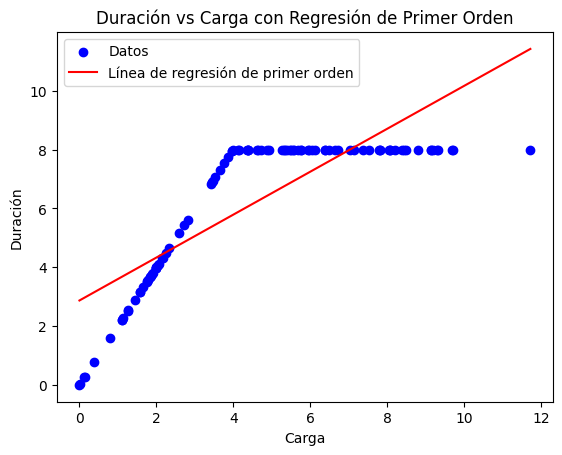

In [9]:
# Gráfica del modelo de primer orden de batería
orden_bateria = np.argsort(x_bateria["carga"].values)

plt.scatter(x_bateria, y_bateria, color="blue", label="Datos")
plt.plot(
    x_bateria["carga"].values[orden_bateria],
    predicciones_bateria_1[orden_bateria],
    color="red",
    label="Línea de regresión de primer orden"
)
plt.xlabel("Carga")
plt.ylabel("Duración")
plt.title("Duración vs Carga con Regresión de Primer Orden")
plt.legend()
plt.show()

## MODELO - B0 + B1X + B2X2 + B3X3 + B4X4 + B5X5

In [10]:
# Modelo de quinto orden de batería
x_bateria_v = np.reshape(x_bateria.values, (-1, 1))

X_bateria_5 = np.hstack([
    x_bateria_v,
    x_bateria_v**2,
    x_bateria_v**3,
    x_bateria_v**4,
    x_bateria_v**5
])

modelo_bateria_5 = LinearRegression()
modelo_bateria_5.fit(X_bateria_5, y_bateria)

predicciones_bateria_5 = modelo_bateria_5.predict(X_bateria_5)
R2_bateria_5 = modelo_bateria_5.score(X_bateria_5, y_bateria)

print("B0:", modelo_bateria_5.intercept_)
print("B1 a B5:", modelo_bateria_5.coef_)
print(f"R² del modelo de quinto orden: {R2_bateria_5:.6f}")
print(f"Porcentaje explicado: {R2_bateria_5 * 100:.2f}%")

B0: [0.14276245]
B1 a B5: [[ 8.35890085e-01  1.10347381e+00 -3.23550360e-01  3.20123836e-02
  -1.07054199e-03]]
R² del modelo de quinto orden: 0.995363
Porcentaje explicado: 99.54%


In [11]:
# Ecuación del modelo de quinto orden de batería
print(
    f"y = {modelo_bateria_5.intercept_[0]:.4f} "
    f"{modelo_bateria_5.coef_[0][0]:+.4f}x "
    f"{modelo_bateria_5.coef_[0][1]:+.4f}x² "
    f"{modelo_bateria_5.coef_[0][2]:+.4f}x³ "
    f"{modelo_bateria_5.coef_[0][3]:+.4f}x⁴ "
    f"{modelo_bateria_5.coef_[0][4]:+.6e}x⁵"
)

y = 0.1428 +0.8359x +1.1035x² -0.3236x³ +0.0320x⁴ -1.070542e-03x⁵


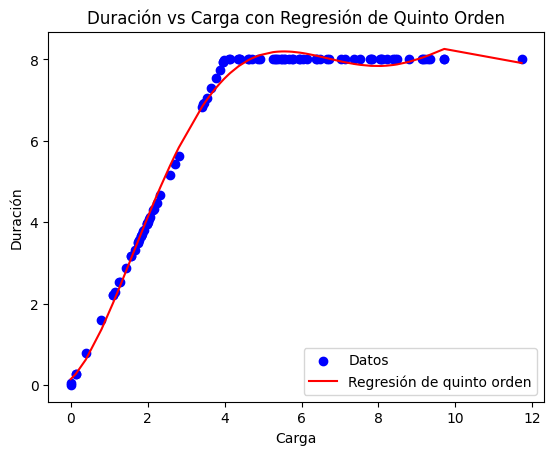

In [12]:
# Gráfica del modelo de quinto orden de batería
orden_bateria = np.argsort(x_bateria_v[:, 0])

plt.scatter(x_bateria_v, y_bateria, color="blue", label="Datos")
plt.plot(
    x_bateria_v[orden_bateria],
    predicciones_bateria_5[orden_bateria],
    color="red",
    label="Regresión de quinto orden"
)
plt.xlabel("Carga")
plt.ylabel("Duración")
plt.title("Duración vs Carga con Regresión de Quinto Orden")
plt.legend()
plt.show()

## MODELO - B0 + B1X + B2X2 + B3X3 + B4X4 + B5X5 + B6X6 + B7X7 + B8X8 + B9X9

In [13]:
# Modelo de noveno orden de batería
X_bateria_9 = np.hstack([
    x_bateria_v,
    x_bateria_v**2,
    x_bateria_v**3,
    x_bateria_v**4,
    x_bateria_v**5,
    x_bateria_v**6,
    x_bateria_v**7,
    x_bateria_v**8,
    x_bateria_v**9
])

modelo_bateria_9 = LinearRegression()
modelo_bateria_9.fit(X_bateria_9, y_bateria)

predicciones_bateria_9 = modelo_bateria_9.predict(X_bateria_9)
R2_bateria_9 = modelo_bateria_9.score(X_bateria_9, y_bateria)

print("B0:", modelo_bateria_9.intercept_)
print("B1 a B9:", modelo_bateria_9.coef_)
print(f"R² del modelo de noveno orden: {R2_bateria_9:.6f}")
print(f"Porcentaje explicado: {R2_bateria_9 * 100:.2f}%")

B0: [-0.03225701]
B1 a B9: [[ 2.37235338e+00 -2.15595582e-01 -4.37810578e-01  5.06419554e-01
  -2.05326541e-01  4.07627631e-02 -4.30680375e-03  2.33074964e-04
  -5.08969063e-06]]
R² del modelo de noveno orden: 0.998913
Porcentaje explicado: 99.89%


In [14]:
# Ecuación del modelo de noveno orden de batería
print(
    f"y = {modelo_bateria_9.intercept_[0]:.4f} "
    f"{modelo_bateria_9.coef_[0][0]:+.4f}x "
    f"{modelo_bateria_9.coef_[0][1]:+.4f}x² "
    f"{modelo_bateria_9.coef_[0][2]:+.4f}x³ "
    f"{modelo_bateria_9.coef_[0][3]:+.4f}x⁴ "
    f"{modelo_bateria_9.coef_[0][4]:+.4f}x⁵ "
    f"{modelo_bateria_9.coef_[0][5]:+.6e}x⁶ "
    f"{modelo_bateria_9.coef_[0][6]:+.6e}x⁷ "
    f"{modelo_bateria_9.coef_[0][7]:+.6e}x⁸ "
    f"{modelo_bateria_9.coef_[0][8]:+.6e}x⁹"
)

y = -0.0323 +2.3724x -0.2156x² -0.4378x³ +0.5064x⁴ -0.2053x⁵ +4.076276e-02x⁶ -4.306804e-03x⁷ +2.330750e-04x⁸ -5.089691e-06x⁹


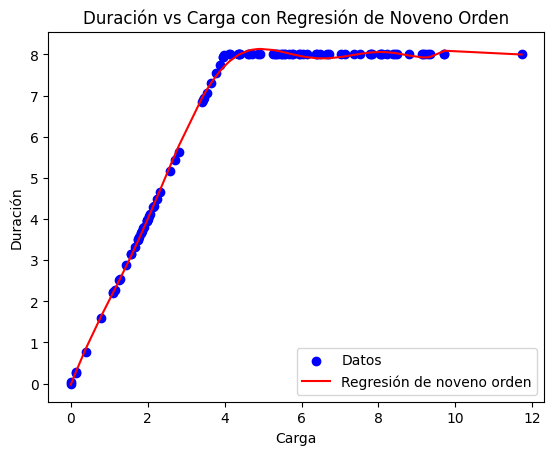

In [15]:
# Gráfica del modelo de noveno orden de batería
orden_bateria = np.argsort(x_bateria_v[:, 0])

plt.scatter(x_bateria_v, y_bateria, color="blue", label="Datos")
plt.plot(
    x_bateria_v[orden_bateria],
    predicciones_bateria_9[orden_bateria],
    color="red",
    label="Regresión de noveno orden"
)
plt.xlabel("Carga")
plt.ylabel("Duración")
plt.title("Duración vs Carga con Regresión de Noveno Orden")
plt.legend()
plt.show()

## **EJERCICIO CON "Salarios_minimos.csv"**

In [16]:
# Leer el archivo "Salarios_minimos.csv"
df_salarios = pd.read_csv("Salarios_minimos.csv")
df_salarios

,Periodo,Salario
0,1988.25,8.00
1,1989.00,8.64
2,1989.50,9.16
3,1990.00,10.08
4,1990.84,11.90
5,1991.84,13.33
6,1993.00,14.27
7,1994.00,15.27
8,1995.00,16.34
9,1995.30,18.30


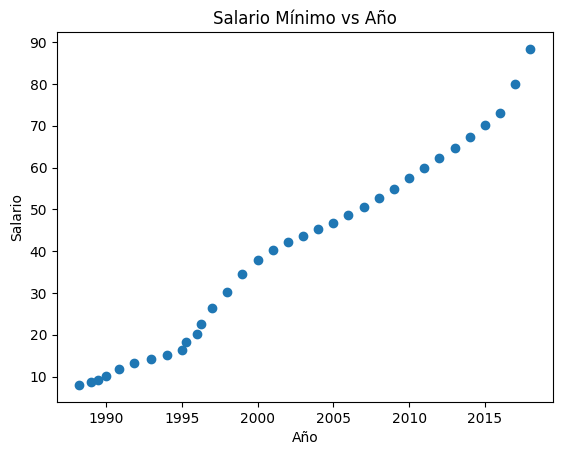

In [17]:
# Variables del ejercicio de salarios
x_salarios = df_salarios["Periodo"]
y_salarios = df_salarios[["Salario"]]

plt.scatter(x_salarios, y_salarios)
plt.xlabel("Año")
plt.ylabel("Salario")
plt.title("Salario Mínimo vs Año")
plt.show()

## MODELO - B0 + B1X

In [18]:
# Modelo de primer orden de salarios
x_salarios_v = np.reshape(x_salarios.values, (-1, 1))

modelo_salarios_1 = LinearRegression()
modelo_salarios_1.fit(x_salarios_v, y_salarios)

predicciones_salarios_1 = modelo_salarios_1.predict(x_salarios_v)
R2_salarios_1 = modelo_salarios_1.score(x_salarios_v, y_salarios)

print("B0:", modelo_salarios_1.intercept_)
print("B1:", modelo_salarios_1.coef_)
print(f"R² del modelo de primer orden: {R2_salarios_1:.6f}")
print(f"Porcentaje explicado: {R2_salarios_1 * 100:.2f}%")

B0: [-5022.60217164]
B1: [[2.52832885]]
R² del modelo de primer orden: 0.984457
Porcentaje explicado: 98.45%


In [19]:
# Ecuación del modelo de primer orden de salarios
print(
    f"y = {modelo_salarios_1.intercept_[0]:.4f} "
    f"{modelo_salarios_1.coef_[0][0]:+.4f}x"
)

y = -5022.6022 +2.5283x


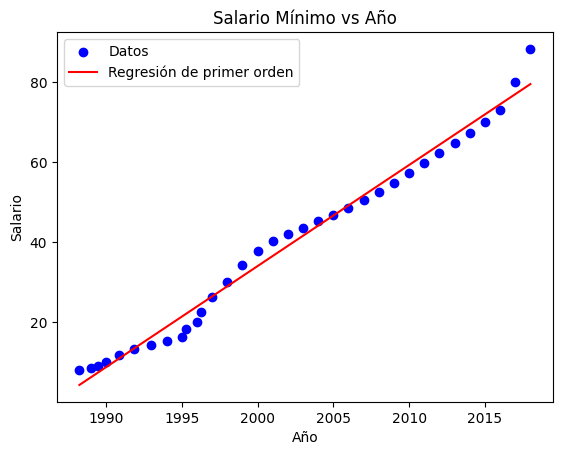

In [20]:
# Gráfica del modelo de primer orden de salarios
plt.scatter(x_salarios, y_salarios, color="blue", label="Datos")
plt.plot(
    x_salarios,
    predicciones_salarios_1,
    color="red",
    label="Regresión de primer orden"
)
plt.xlabel("Año")
plt.ylabel("Salario")
plt.title("Salario Mínimo vs Año")
plt.legend()
plt.show()

## MODELO - B0 + B1X + B2X2 + B3X3 + B4X4 + B5X5

In [21]:
# Modelo de quinto orden de salarios
# Para este modelo: t = Periodo - 1988.25
t_salarios = np.reshape(x_salarios.values - 1988.25, (-1, 1))

X_salarios_5 = np.hstack([
    t_salarios,
    t_salarios**2,
    t_salarios**3,
    t_salarios**4,
    t_salarios**5
])

modelo_salarios_5 = LinearRegression()
modelo_salarios_5.fit(X_salarios_5, y_salarios)

predicciones_salarios_5 = modelo_salarios_5.predict(X_salarios_5)
R2_salarios_5 = modelo_salarios_5.score(X_salarios_5, y_salarios)

print("B0:", modelo_salarios_5.intercept_)
print("B1 a B5:", modelo_salarios_5.coef_)
print(f"R² del modelo de quinto orden: {R2_salarios_5:.6f}")
print(f"Porcentaje explicado: {R2_salarios_5 * 100:.2f}%")

B0: [9.5359274]
B1 a B5: [[-1.20276641e+00  5.76886218e-01 -2.99998494e-02  4.54189951e-04
   1.59814416e-06]]
R² del modelo de quinto orden: 0.996152
Porcentaje explicado: 99.62%


In [22]:
# Ecuación del modelo de quinto orden de salarios
# t = Periodo - 1988.25
print(
    f"y = {modelo_salarios_5.intercept_[0]:.6f} "
    f"{modelo_salarios_5.coef_[0][0]:+.6f}t "
    f"{modelo_salarios_5.coef_[0][1]:+.6f}t² "
    f"{modelo_salarios_5.coef_[0][2]:+.6f}t³ "
    f"{modelo_salarios_5.coef_[0][3]:+.6e}t⁴ "
    f"{modelo_salarios_5.coef_[0][4]:+.6e}t⁵"
)
print("Donde t = Periodo - 1988.25")

y = 9.535927 -1.202766t +0.576886t² -0.030000t³ +4.541900e-04t⁴ +1.598144e-06t⁵
Donde t = Periodo - 1988.25


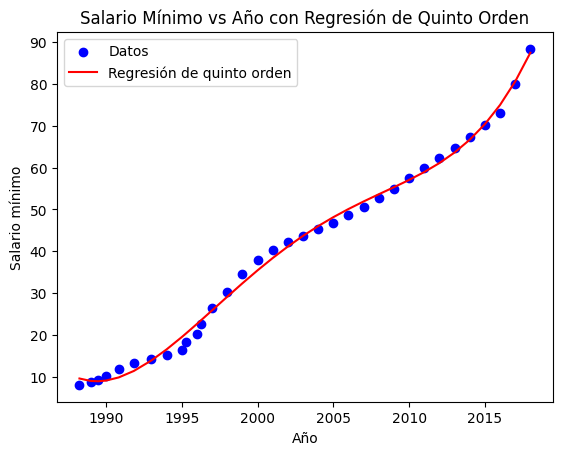

In [23]:
# Gráfica del modelo de quinto orden de salarios
plt.scatter(x_salarios, y_salarios, color="blue", label="Datos")
plt.plot(
    x_salarios,
    predicciones_salarios_5,
    color="red",
    label="Regresión de quinto orden"
)
plt.xlabel("Año")
plt.ylabel("Salario mínimo")
plt.title("Salario Mínimo vs Año con Regresión de Quinto Orden")
plt.legend()
plt.show()

## MODELO - B0 + B1X + B2X2 + B3X3 + B4X4 + B5X5 + B6X6 + B7X7 + B8X8 + B9X9

In [24]:
# Modelo de noveno orden de salarios
# Para este modelo: t = Periodo - 1988.25
X_salarios_9 = np.hstack([
    t_salarios,
    t_salarios**2,
    t_salarios**3,
    t_salarios**4,
    t_salarios**5,
    t_salarios**6,
    t_salarios**7,
    t_salarios**8,
    t_salarios**9
])

modelo_salarios_9 = LinearRegression()
modelo_salarios_9.fit(X_salarios_9, y_salarios)

predicciones_salarios_9 = modelo_salarios_9.predict(X_salarios_9)
R2_salarios_9 = modelo_salarios_9.score(X_salarios_9, y_salarios)

print("B0:", modelo_salarios_9.intercept_)
print("B1 a B9:", modelo_salarios_9.coef_)
print(f"R² del modelo de noveno orden: {R2_salarios_9:.6f}")
print(f"Porcentaje explicado: {R2_salarios_9 * 100:.2f}%")

B0: [7.84770056]
B1 a B9: [[-1.75672777e-01  2.17573588e+00 -9.98659695e-01  2.05903916e-01
  -2.18796289e-02  1.29978143e-03 -4.37377244e-05  7.80162908e-07
  -5.73465764e-09]]
R² del modelo de noveno orden: 0.999466
Porcentaje explicado: 99.95%


In [25]:
# Ecuación del modelo de noveno orden de salarios
# t = Periodo - 1988.25
print(
    f"y = {modelo_salarios_9.intercept_[0]:.6f} "
    f"{modelo_salarios_9.coef_[0][0]:+.6f}t "
    f"{modelo_salarios_9.coef_[0][1]:+.6f}t² "
    f"{modelo_salarios_9.coef_[0][2]:+.6f}t³ "
    f"{modelo_salarios_9.coef_[0][3]:+.6f}t⁴ "
    f"{modelo_salarios_9.coef_[0][4]:+.6e}t⁵ "
    f"{modelo_salarios_9.coef_[0][5]:+.6e}t⁶ "
    f"{modelo_salarios_9.coef_[0][6]:+.6e}t⁷ "
    f"{modelo_salarios_9.coef_[0][7]:+.6e}t⁸ "
    f"{modelo_salarios_9.coef_[0][8]:+.6e}t⁹"
)
print("Donde t = Periodo - 1988.25")

y = 7.847701 -0.175673t +2.175736t² -0.998660t³ +0.205904t⁴ -2.187963e-02t⁵ +1.299781e-03t⁶ -4.373772e-05t⁷ +7.801629e-07t⁸ -5.734658e-09t⁹
Donde t = Periodo - 1988.25


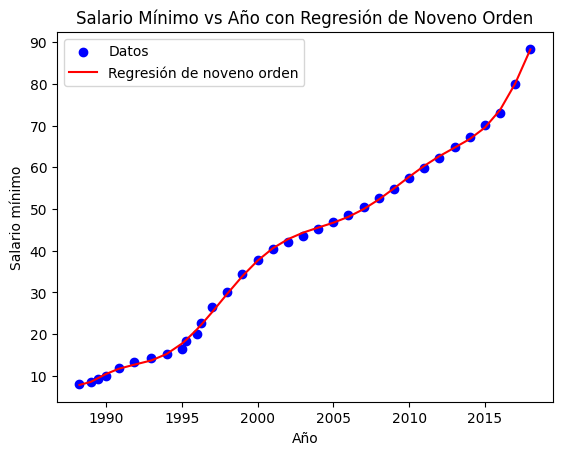

In [26]:
# Gráfica del modelo de noveno orden de salarios
plt.scatter(x_salarios, y_salarios, color="blue", label="Datos")
plt.plot(
    x_salarios,
    predicciones_salarios_9,
    color="red",
    label="Regresión de noveno orden"
)
plt.xlabel("Año")
plt.ylabel("Salario mínimo")
plt.title("Salario Mínimo vs Año con Regresión de Noveno Orden")
plt.legend()
plt.show()